# Feature dictionary -- plain language

Feature	Meaning
-months_as_customer	How long the person has been a customer (often in months since first policy or similar).
-age	Insured person’s age (years).
-policy_number	Internal ID for the policy — identifier, not a “strength” of the claim; usually drop for modeling or keep only for deduplication.
-policy_bind_date	Date the policy was bound / started.
-policy_state	U.S. state where the policy was issued.
-policy_csl	Combined single limits (e.g. 250/500) — liability coverage split; text in the file, often parsed or one-hot.
-policy_deductable	Deductible amount the customer pays before insurance pays (same idea as “deductible”; typo “deductable” in column name).
-policy_annual_premium	Yearly premium paid for the policy.
-umbrella_limit	Extra liability coverage above the main policy (0 if none).
-insured_zip	ZIP code of the insured (often treated as numeric or binned; watch privacy in real projects).
-insured_sex	Sex/gender of the insured (as recorded in the data).
-insured_education_level	Education level (e.g. High School, PhD).
-insured_occupation	Occupation category.
-insured_hobbies	Hobby category (dataset-specific categories).
-insured_relationship	Relationship to policyholder (e.g. wife, own-child).
-capital-gains	Reported capital gains (money context in the dataset).
-capital-loss	Reported capital losses.
-ncident_date	Date the incident happened.
-ncident_type	What kind of incident (e.g. collision, theft).
-collision_type	How vehicles collided (e.g. rear, side), or missing if not a collision.
-incident_severity	How bad the damage was (e.g. minor, total loss).
-authorities_contacted	Which authorities were notified (police, fire, none, etc.).
-ncident_state	State where the incident occurred.
-cident_city	City where the incident occurred.
-incident_location	Street address or location text of the incident.
-incident_hour_of_the_day	Hour (0–23) when the incident occurred.
number_of_vehicles_involved	Count of vehicles involved.
-property_damage	Whether property (non-vehicle) was damaged — often YES/NO/unknown.
-bodily_injuries	Count or level of bodily injury (numeric in this file).
-witnesses	Number of witnesses (or coded).
-police_report_available	Whether a police report exists — YES/NO/unknown.
-total_claim_amount	Total dollar amount of the claim.
-injury_claim	Dollar amount for injury portion.
-property_claim	Dollar amount for property portion.
-ehicle_claim	Dollar amount for vehicle damage portion.
-auto_make	Vehicle manufacturer.
-uto_model	Vehicle model.
-auto_year	Model year of the vehicle.
-fraud_reported	Target for fraud modeling — whether fraud was reported (Y/N).
-_c39	Spurious empty column from export — drop; not a real feature.

Use the command below to install the libraries

In [3]:
!pip install pandas 
!pip install seaborn 
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


First, we import our libraries, pandas is to read the data, seaborn and matplotlib for visualizations and numpy for data manipulation

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
# --- Path: folder containing this notebook/script ---
DATA_PATH = Path(r"C:\Users\VICTUS\Documents\GITHUB\Tech-crush\techcursh-practice\insurance_claims.csv")


we want to load data inconsistencies and turn ?, "", NA, etc. into real NaN so isnull() tells the truth

In [4]:
df = pd.read_csv(
    DATA_PATH,
    na_values=["?", "", "NA", "N/A", "nan", "NaN"],
    keep_default_na=True,
)

The first thing is to check the general information about your dataset. what is in it and what the data types are. 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

Here, as discussed in class, we want to check if there are any missing columns, records or data points. and that is why we are using the .isnull() method and the sum function. 

The sum() as it says is just to add all the missing columns

In [6]:
missing_values = df.isnull().sum()
print(missing_values)

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                  178
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

Remaining NaNs (after na_values=["?", ...])
These are not bugs — they are places where the file had ? or blank for “unknown”:

Column	Missing 
collision_type	178	 Type of collision not recorded / not applicable (e.g. theft).
property_damage	360	-> Unknown whether property was damaged.
police_report_available	->343	Unknown if a police report exists.
authorities_contacted	-> 91	Who was contacted — truly empty in some rows.




From the result above, we can see that the _c39 has 1000 rows missing, which is essentially all the rows.. that tells us that we do not need it and based on the the data cleaning techniques that we discussed, we can use the deletion technique -> that will be done by droping the column

we can also see other feature(columns) with missing columns as well.

In [7]:
#Drop the _c39 column
df.drop('_c39', axis=1, inplace=True)

# STRIP whitespace on object columns (avoids "YES " vs " YES" VS "YES")

But dropping _c39 row is not all, we have to check and strip white spaces(white spaces are the invisible spaces before or around data, most times before.. 
for example "Yes" is different from " Yes")

In [20]:
obj_cols = df.select_dtypes(include=["object"]).columns
for col in obj_cols:
    df[col] = df[col].str.strip()

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\949027867.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=["object"]).columns


COLUMNS THAT WERE YES / NO / ? — after step 1, ? is NaN
Give unknowns an explicit label so encoding is consistent (good for trees).

we have some columns with missing data, based on what we did in step 1, when we loaded our data with pandas. but since we have the number of rows with inconsistent data, and we know them to be categorical variables, we have two rule or thumb;

Categorical: fillna("UNKNOWN")
Numeric: pd.to_numeric + median imputation after train/test split, or similar

We use UNKNOWN so the model can treat ‘not reported’ differently from ‘reported NO’.

We preserve information that “we don’t know” is different from “we know it’s NO.

In [21]:
# --- Categorical columns where missing means "not recorded" → explicit label ---
unknown_cats = [
    "collision_type",
    "property_damage",
    "police_report_available",
    "authorities_contacted",
]

In [22]:

for col in unknown_cats:
    if col in df.columns:
        df[col] = df[col].fillna("UNKNOWN")

normalize YES/NO columns so UNKNOWN is not mixed with case variants ---


Here “normalize” does not mean Min–max scaling to [0, 1] or z-score scaling. Those are numeric feature scaling steps.

In that comment, normalize means make the text labels consistent — one spelling and one case per meaning — so yes / Yes / YES all become YES, and no / No / NO all become NO.

Why it matters: If you one-hot encode or count categories, pandas treats YES and yes as two different categories. That splits the same real-world answer across two columns and confuses the model.

Clearer names for this step (for your notebook):

“Standardize YES/NO labels to uppercase”
“Canonicalize categorical strings”
“Unify case variants”

you can also call this process standardization mainly for categorical variables


In [23]:
for col in ["property_damage", "police_report_available"]:
    if col in df.columns:
        df[col] = df[col].replace(
            {"yes": "YES", "no": "NO", "Yes": "YES", "No": "NO"}
        )

In [24]:
#check if the missing values are now filled
print(df[unknown_cats].isna().sum())

collision_type             0
property_damage            0
police_report_available    0
authorities_contacted      0
dtype: int64


In [25]:
#for safe measure, we can fill the missing values with UNKNOWN
for col in unknown_cats:
    if col in df.columns:
        df[col] = df[col].fillna("UNKNOWN")

In [26]:
missing_values = df.isnull().sum()
print(missing_values)

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

That pattern usually appears on binary Y/N-style columns (e.g. property_damage, police_report_available, or similar).

What to do:

Treat ? as unknown, same as missing:
Map to NaN then impute, or
Map to a label "Unknown" for one-hot encoding.
Do not leave ? as a third “normal” category without thinking — it’s not the same as YES/NO; it’s missing/uncertain (unless you explicitly want a three-way label for teaching).
For modeling, many workflows use:

YES → 1, NO → 0, ? → NaN → then impute or "Unknown".

In [27]:
unique_values = df['police_report_available'].unique()
unique_values

<StringArray>
['YES', 'UNKNOWN', 'NO']
Length: 3, dtype: str

we can see that the _c39 rows are not there again. that means, it has been deleted (dropped) 

Also we now checked for the unique values from one of the column, poloce report, and it correctly shows the three data types that we filled after data cleaning and all. 

In [28]:
anomalies = df[df.isin(['?', 'N/A', 'NaN']).any(axis=1)]
print("Rows with anomalies:\n", anomalies)

Rows with anomalies:
 Empty DataFrame
Columns: [months_as_customer, age, policy_number, policy_bind_date, policy_state, policy_csl, policy_deductable, policy_annual_premium, umbrella_limit, insured_zip, insured_sex, insured_education_level, insured_occupation, insured_hobbies, insured_relationship, capital-gains, capital-loss, incident_date, incident_type, collision_type, incident_severity, authorities_contacted, incident_state, incident_city, incident_location, incident_hour_of_the_day, number_of_vehicles_involved, property_damage, bodily_injuries, witnesses, police_report_available, total_claim_amount, injury_claim, property_claim, vehicle_claim, auto_make, auto_model, auto_year, fraud_reported]
Index: []

[0 rows x 39 columns]


From the above result, we can now see that our data does not contain anomalies again, since we have handled them explicitly by writing "UNKNOWN" so we have clean and accurate data


one more thing to handle is the date, 

Dates — pd.to_datetime(..., errors="coerce")
Goal: Turn policy_bind_date and incident_date into real datetime values.
errors="coerce": Bad or unparseable dates become NaT (“not a time”), pandas’ missing datetime.
Why: So you can compute durations, year/month/day, weekend vs weekday, etc.

We have successfully treated data cleaning at its core, 

Handling missing data
Removing duplicates
Correcting inconsistencies

we will see outliers if any later on

In [31]:
# DATES — parse to datetime (invalid → NaT)

for col in ["policy_bind_date", "incident_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [32]:
#saving the cleaned data to a new csv file
df.to_csv('cleaned_insurance_claims.csv', index=False)

# EDA - Exploratory Data Analysis

Definition: Exploring the data before heavy modeling: shapes, types, missingness, distributions, relationships, and obvious problems. Goal: understand what you have, not to “optimize accuracy” yet.

# Outliers
Definition: Values unusually far from most of the data (for a given feature or in a scatter). Not always errors, can be real (very large claims). Goal: decide whether to investigate, transform (e.g. log), cap, or use models robust to extremes (trees).

# Feature engineering
Definition: Creating new columns from existing ones (dates, ratios, bins) so patterns are easier for the model to use.

# Feature scaling — Standardization vs Normalization
Standardization (z-score): (z = (x - \mu) / \sigma). Mean ≈ 0, std ≈ 1. Sensitive to outliers (mean/std move if extremes exist).
Normalization (min–max): (x' = (x - x_{\min}) / (x_{\max} - x_{\min})). Often mapped to [0, 1]. Very sensitive to outliers (one huge max stretches the rest).

# Feature selection
Definition: Choosing which inputs to keep.

Correlation: linear relationship with the target (or between features).
Univariate tests: score each feature alone vs target (e.g. mutual information, F-test) — ignores feature interactions unless you engineered them.

Of course the first thing to do is to read our cleaned data into our data frame 

In [46]:
from pathlib import Path

# Parse dates so .dt works if we engineer from df1 without going through add_engineered_features again.
CLEANED = Path("cleaned_insurance_claims.csv")
df1 = pd.read_csv(
    CLEANED,
    parse_dates=["policy_bind_date", "incident_date"],
)
df1.head()


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,UNKNOWN,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [47]:
print("shape:", df1.shape)
print(df1.dtypes)
print("\nMissing per column (top 15):\n", df1.isna().sum().sort_values(ascending=False).head(15))
#check for missing values
missing_values = df1.isnull().sum()
print("\nMissing per column (top 15):\n", missing_values.sort_values(ascending=False).head(15))
#check for duplicates
duplicates = df1.duplicated()
print("\nNumber of duplicates:", duplicates.sum())


shape: (1000, 39)
months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                   str
policy_state                       str
policy_csl                         str
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                        str
insured_education_level            str
insured_occupation                 str
insured_hobbies                    str
insured_relationship               str
capital-gains                    int64
capital-loss                     int64
incident_date                      str
incident_type                      str
collision_type                     str
incident_severity                  str
authorities_contacted              str
incident_state                     str
incident_city                      str
incident_location                  str
inciden

In [48]:
# Binary fraud label for plots and correlation (does not replace fraud_reported in df1)
df1["fraud_binary"] = (df1["fraud_reported"].astype(str).str.upper().str.strip() == "Y").astype(int)
print("\nFraud counts:\n", df1["fraud_reported"].value_counts())
print("Fraud rate (Y):", df1["fraud_binary"].mean())





Fraud counts:
 fraud_reported
N    753
Y    247
Name: count, dtype: int64
Fraud rate (Y): 0.247


In [49]:
display(df1.select_dtypes(include=[np.number]).describe())


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,fraud_binary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,0.247000
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,0.431483
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,0.000000
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,0.000000
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,0.000000
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,0.000000
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,1.000000


In [50]:
# Correlation with fraud (linear relationships only)
num_for_corr = df1.select_dtypes(include=[np.number]).columns
corr_to_fraud = df1[num_for_corr].corr(numeric_only=True)["fraud_binary"].drop("fraud_binary").abs().sort_values(ascending=False)
print("\nTop |correlation| with fraud_binary:\n", corr_to_fraud.head(12))



Top |correlation| with fraud_binary:
 vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
policy_number                  0.029443
months_as_customer             0.020544
insured_zip                    0.019368
capital-gains                  0.019173
Name: fraud_binary, dtype: float64


Correlation (here, usually Pearson) measures how two numeric variables move together in a straight-line sense:

A correlation matrix is a table where every numeric column is correlated with every other numeric column. Entry ((i, j)) is the correlation between variable (i) and variable (j). It is symmetric: the matrix looks the same above and below the diagonal.


Why we use it in EDA

See which features “move together” (redundant signals → multicollinearity for linear models).
Spot structural links in the data (e.g. claim components adding up to total).
Get a first sense of what might relate to the target if the target is numeric (you added fraud_binary as 0/1, so correlations with it are still “linear association with fraud”).
What it does not do

It does not use raw text (states, cities) until those are encoded as numbers.
It does not capture nonlinear patterns well.
It does not prove causation.

+1: when one goes up, the other tends to go up (perfect positive linear relationship).



0: no linear relationship (they might still relate in a curved way—correlation won’t show that).

−1: when one goes up, the other tends to go down.

The heatmap is a compact map of linear relationships between numbers; strong blocks often mean redundancy or structure; a weak row for the target means fraud is not explained by one numeric feature alone in a straight-line way.

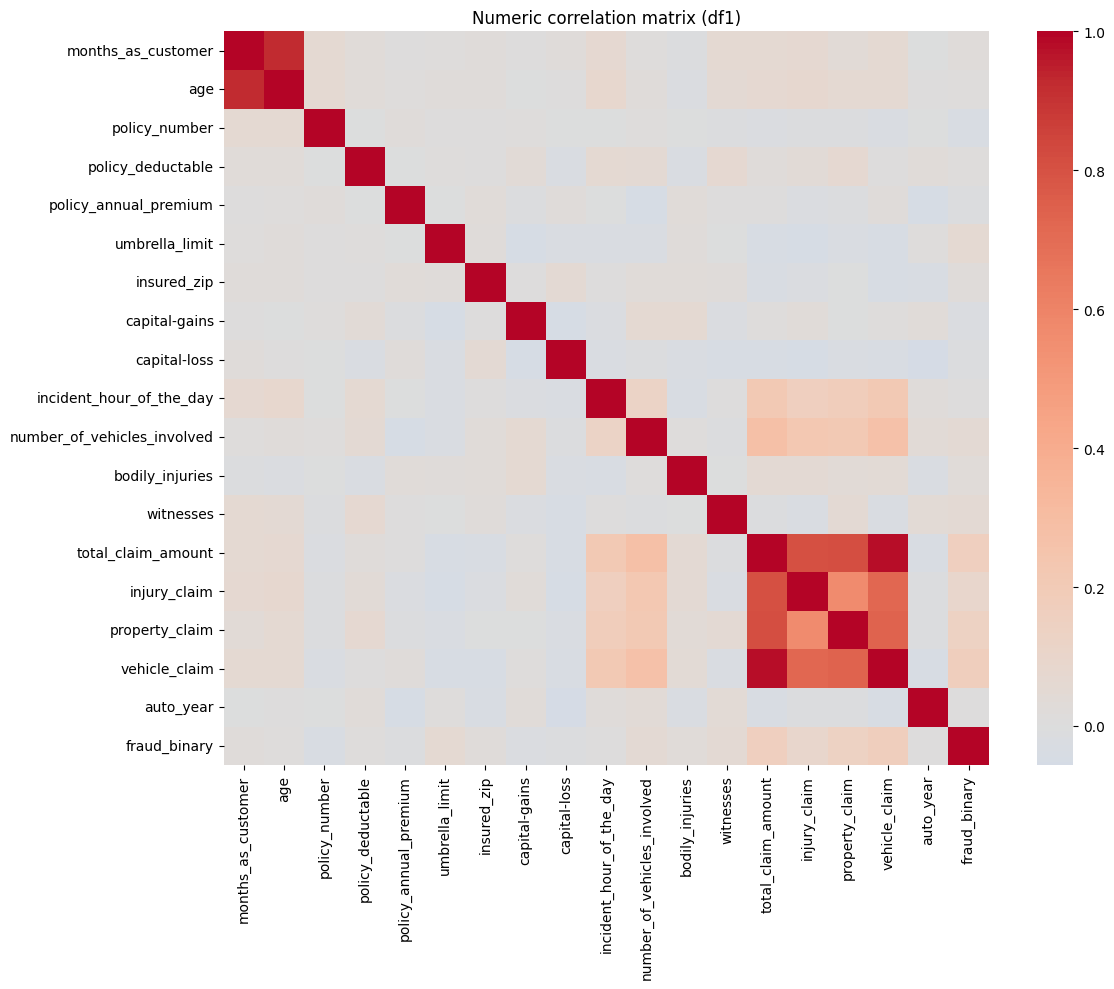

In [51]:
# Heatmap of numeric correlations (optional; can be slow if many columns)
plt.figure(figsize=(12, 10))
sns.heatmap(df1[num_for_corr].corr(), cmap="coolwarm", center=0)
plt.title("Numeric correlation matrix (df1)")
plt.tight_layout()
plt.show()

Pearson correlation measures linear relationships between numbers only.
Categorical columns (state, city, YES/NO strings) must be encoded (e.g. one-hot) before they can enter a numeric correlation matrix—or you use other EDA (counts, grouped fraud rates), not corr() on raw strings.

You plotted the numeric correlation matrix for df1 (with fraud_binary included). In plain terms:

Diagonal (dark red, 1.0)
Each variable is perfectly correlated with itself. That is expected.

age vs months_as_customer (strong red)
Older people in this sample tend to have been customers longer. That is a strong positive linear association—often real in insurance data (tenure grows with age on average).

Claim block: total_claim_amount, injury_claim, property_claim, vehicle_claim (big red block)
These move together because they are parts of the same story (amounts that make up or track the overall claim). Very high correlation here often means redundancy: a model might not need all four if one carries almost the same information (or they are definitionally linked).

fraud_binary row/column (mostly pale)
Most correlations with fraud are weak. That means no single numeric column has a strong simple linear relationship with fraud by itself. That is normal for fraud—and it motivates more features, non-linear models, or combinations of variables, not “fraud is explained by one number.”

Many pale / near-zero cells
Lots of pairs (e.g. identifiers or weakly related fields) do not linearly co-move. That is also expected.

# Key observations from the correlation matrix:

**What the quartiles and IQR are**
Sort total_claim_amount from smallest to largest.

Q1 (25th percentile): 25% of values are below this; 75% are above.
Q3 (75th percentile): 75% of values are below this; 25% are above.
IQR (interquartile range) = Q3 − Q1
It is the width of the middle 50% of the data (the box in a boxplot). It measures spread in a way that ignores the most extreme low and high values (unlike the full range min→max).

So: IQR = how spread out the “typical middle” of the amounts is.

How IQR relates to “outliers” (the 1.5×IQR rule)
A common rule (Tukey’s fences, same idea as the whiskers in a boxplot) builds two cutoffs:

Lower fence: Q1 − 1.5 × IQR
Upper fence: Q3 + 1.5 × IQR
Any point below the lower fence or above the upper fence is often flagged as an outlier for that variable.

So IQR is not “the outliers”; it is used to set how far from the middle box we allow values before we call them unusually extreme relative to the rest of the distribution.

In [44]:
# Using IQR to identify outliers
Q1 = df['total_claim_amount'].quantile(0.25)
Q3 = df['total_claim_amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['total_claim_amount'] < (Q1 - 1.5 * IQR)) | (df['total_claim_amount'] > (Q3 + 1.5 * IQR))]
print("Number of outliers:", len(outliers))

# Handling outliers (e.g., capping or removing)
df['total_claim_amount'] = np.where(df['total_claim_amount'] > (Q3 + 1.5 * IQR), (Q3 + 1.5 * IQR), df['total_claim_amount'])

Number of outliers: 1


Why we got “Number of outliers: 1”
Our code counts rows where total_claim_amount is outside those fences. 1 means: only one row in your current dataframe is beyond the upper or lower fence (usually above the upper fence for money, because claims are right-skewed but the fence can still be high).

So: only one claim amount is extreme enough by this rule—not that the data has only one large claim in absolute terms, but only one crosses the IQR-based threshold you computed.

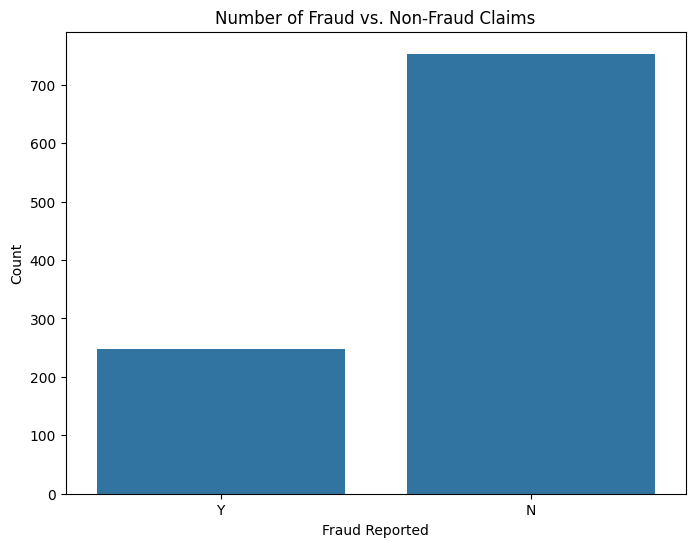

In [45]:
plt.figure(figsize=(8, 6))
sns.countplot(x='fraud_reported', data=df)
plt.title('Number of Fraud vs. Non-Fraud Claims')
plt.xlabel('Fraud Reported')
plt.ylabel('Count')
plt.show()

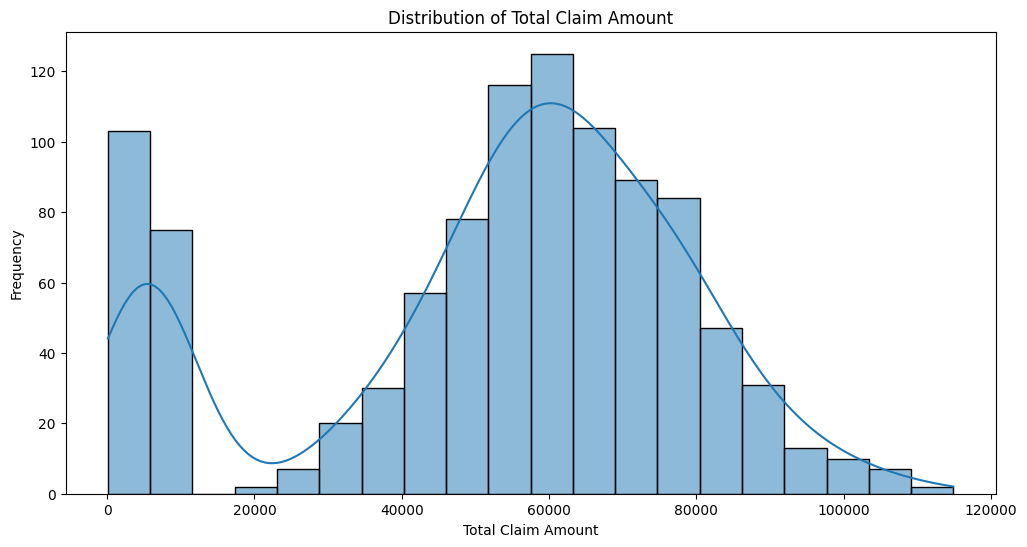

In [40]:
plt.figure(figsize=(12, 6))
sns.histplot(df['total_claim_amount'], kde=True)
plt.title('Distribution of Total Claim Amount')
plt.xlabel('Total Claim Amount')
plt.ylabel('Frequency')
plt.show()

The most frequent claim amounts are around 60,000, with a noticeable peak in this range.

There is a smaller peak around 0, indicating a significant number of low claim amounts.

The distribution is right-skewed, meaning there are fewer high claim amounts as the value increases.


claim amounts are right-skewed (a few very large values); outliers in money columns are common in insurance. Tree models are often less sensitive to scaling/outliers than distance-based models; standardization still matters for logistic regression and neural nets.

## Outliers and scatter plots

**Outlier:** a value unusually far from most others for that feature (or a point far from the bulk in a scatter). Large insurance claims often look like outliers but can be **valid** (severe accidents). Scatter plots help you **see** heavy tails and separation by fraud; they do not by themselves prove an error.

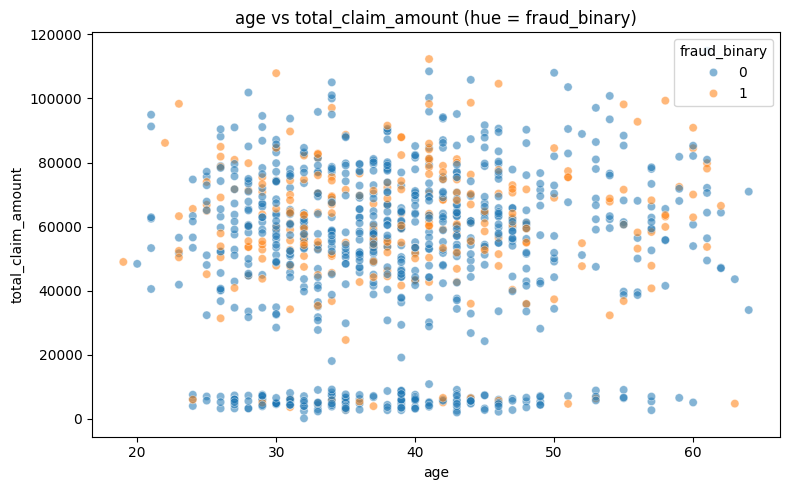

In [52]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df1,
    x="age",
    y="total_claim_amount",
    hue="fraud_binary",
    alpha=0.55,
)
plt.title("age vs total_claim_amount (hue = fraud_binary)")
plt.tight_layout()
plt.show()

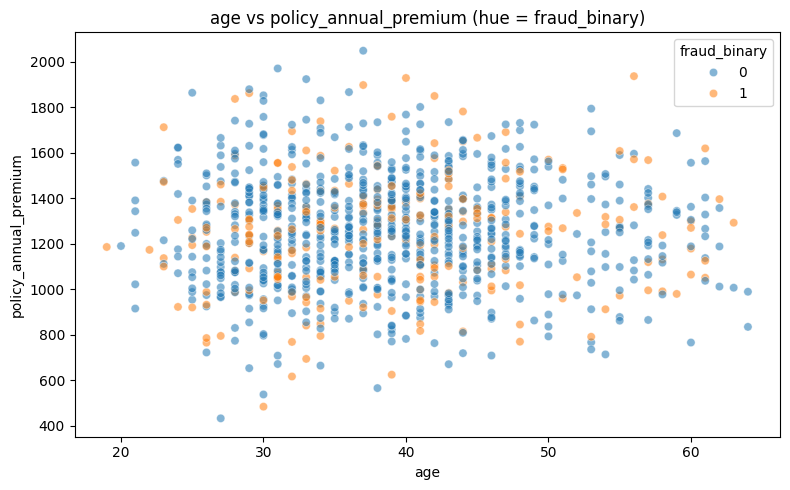

In [53]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df1,
    x="age",
    y="policy_annual_premium",
    hue="fraud_binary",
    alpha=0.55,
)
plt.title("age vs policy_annual_premium (hue = fraud_binary)")
plt.tight_layout()
plt.show()

A **scatter plot** puts one numeric variable on x, another on y, one point per row. You colored points by fraud_binary (“hue”), so you can see whether fraud and non-fraud separate in that 2D space.

age vs total_claim_amount: Claim sizes span a huge range; many points sit in a dense band; a few very high claims look like outliers on the y-axis. Orange (fraud) and blue (non-fraud) are mixed, so age and total amount alone do not draw a clean boundary—matches the weak fraud correlations in the matrix.
age vs policy_annual_premium: Premiums sit in a fairly tight band across ages (a cloud more than a line). Again, colors are mixed—premium alone does not separate fraud clearly.

Why we use these

See range, skew, clusters, and extreme points (outliers / heavy tails).
See whether two features separate classes visually (here: not much separation → need richer features or a model that combines many inputs).

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\3870322779.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='total_claim_amount', y='vehicle', data=vehicle_claims, palette='viridis', ci=None)
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\3870322779.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_claim_amount', y='vehicle', data=vehicle_claims, palette='viridis', ci=None)


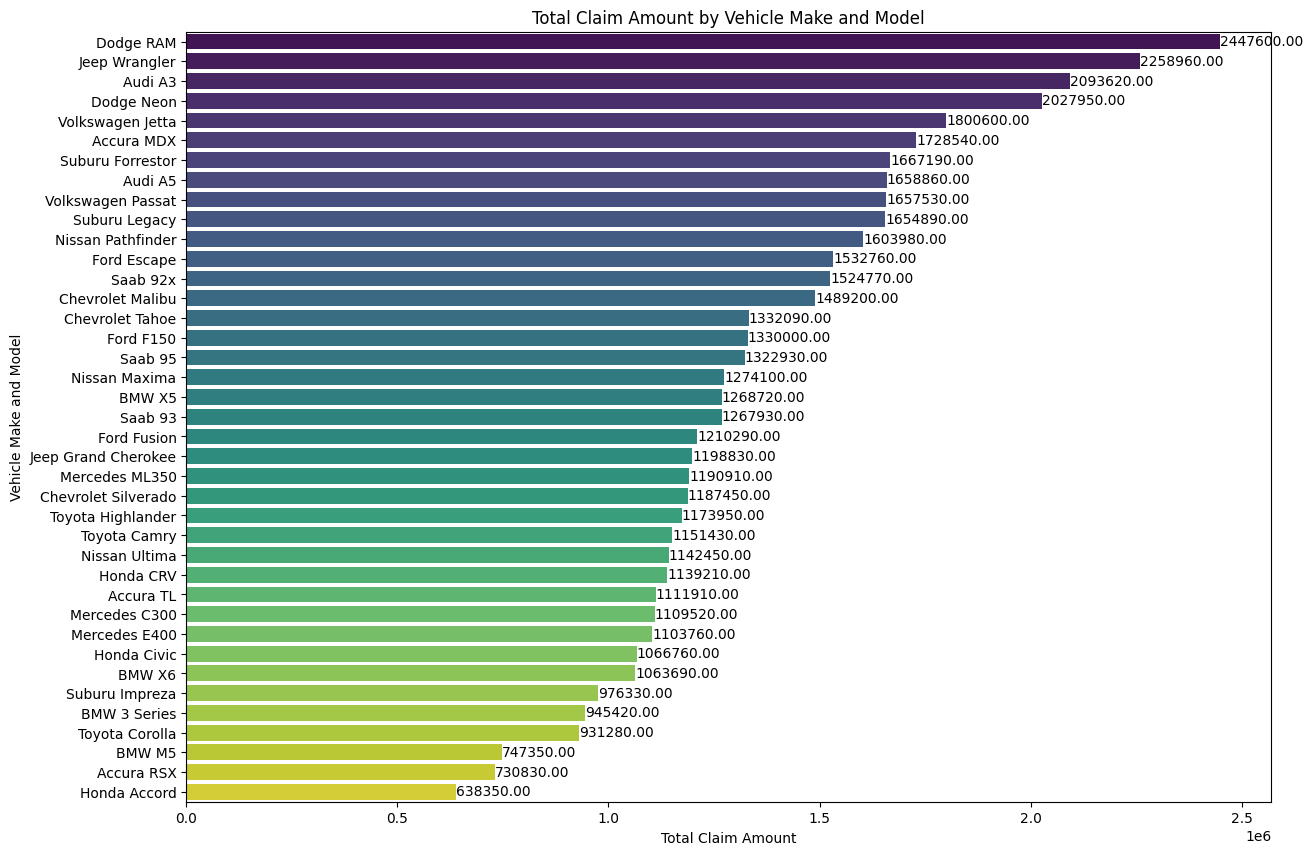

In [59]:
# Combine make and model into a single column
df['vehicle'] = df['auto_make'] + ' ' + df['auto_model']

# Aggregate total claim amount by vehicle
vehicle_claims = df.groupby('vehicle')['total_claim_amount'].sum().reset_index()

# Sort the data by total claim amount
vehicle_claims = vehicle_claims.sort_values(by='total_claim_amount', ascending=False)

# Create a horizontal bar chart
plt.figure(figsize=(14, 10))
sns.barplot(x='total_claim_amount', y='vehicle', data=vehicle_claims, palette='viridis', ci=None)
plt.title('Total Claim Amount by Vehicle Make and Model')
plt.xlabel('Total Claim Amount')
plt.ylabel('Vehicle Make and Model')

# Add labels to the bars
for index, value in enumerate(vehicle_claims['total_claim_amount']):
    plt.text(value, index, f'{value:.2f}', color='black', ha="left", va="center")

plt.show()

What it shows: Which vehicle types contribute the most total money to claims (stack of all rows for that type).

How it affects insight: It answers “where is the money?” — e.g. a few models can dominate total exposure. That pairs with your 0.57: models at the top of this chart are often the same ones that show up with high fraud counts in the scatter — but the bar chart alone does not show fraud; it only shows dollars.

Why it’s needed: Prioritization (“which segments to study or monitor first”) and context for volume vs severity.

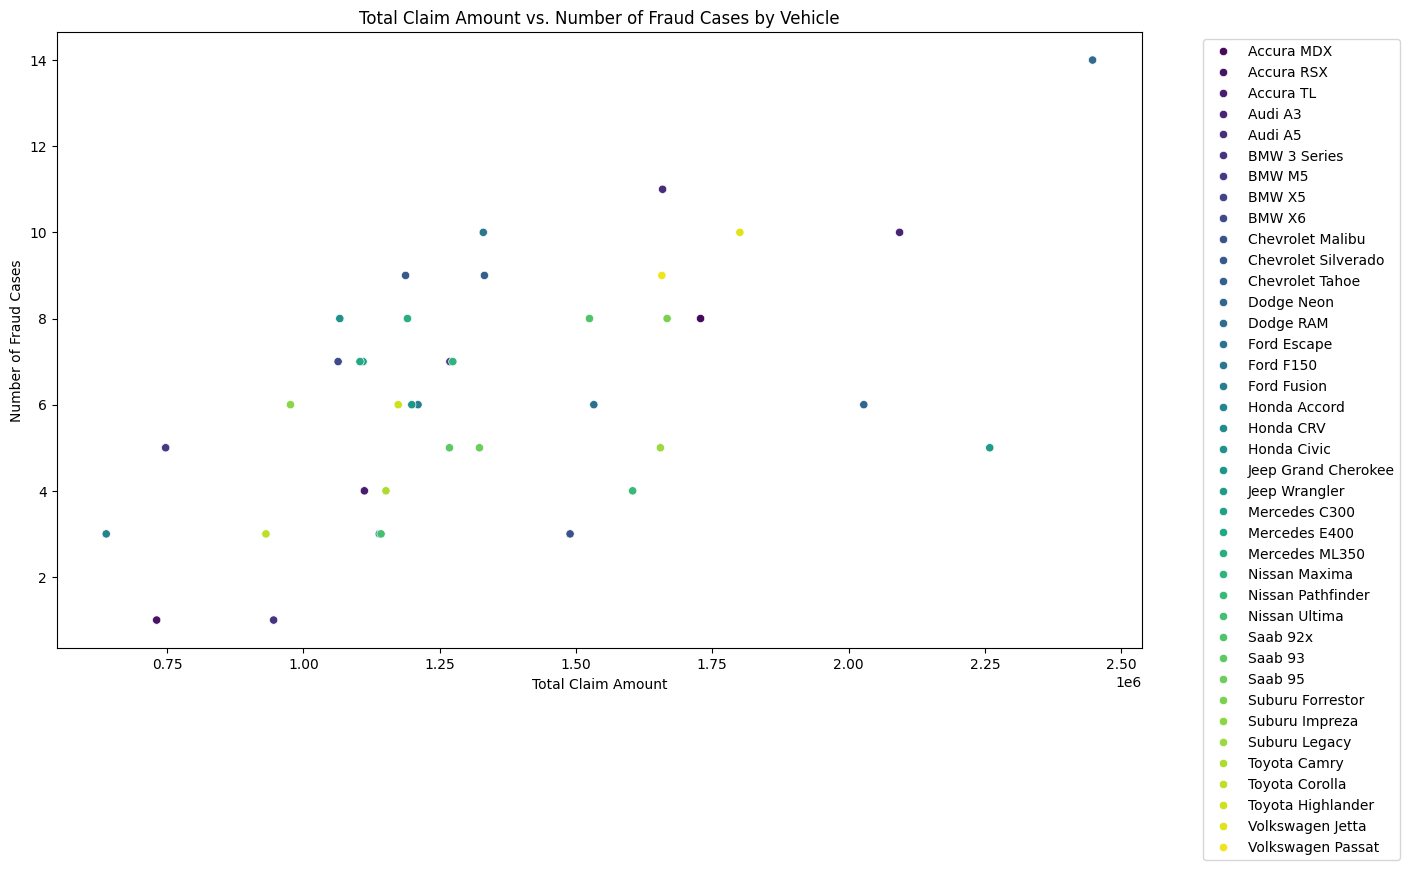

In [60]:
df1['vehicle'] = df1['auto_make'] + ' ' + df1['auto_model']

# Aggregate total claim amount and fraud count by vehicle
vehicle_fraud = df1.groupby('vehicle').agg({
    'total_claim_amount': 'sum',
    'fraud_reported': lambda x: (x == 'Y').sum()
}).reset_index()

# Create a scatter plot
plt.figure(figsize=(14, 8))
sns.scatterplot(x='total_claim_amount', y='fraud_reported', data=vehicle_fraud, hue='vehicle', palette='viridis')
plt.title('Total Claim Amount vs. Number of Fraud Cases by Vehicle')
plt.xlabel('Total Claim Amount')
plt.ylabel('Number of Fraud Cases')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

What it shows: Each point is a vehicle type; x = sum of claim amount, y = count of frauds. The cloud trending upward matches positive correlation (~0.57): more total dollars ↔ more fraud cases at the vehicle level.

How it affects insight: It visualizes the same relationship your correlation summarizes. You see scatter (not a perfect line) → correlation is moderate, not ~1. You can also spot exceptions (e.g. high dollars but fewer frauds, or the opposite) for class discussion.

Why it’s needed: Correlation is one number; the plot shows spread, outliers, and exceptions that the number hides.

In [61]:
df1['vehicle'] = df1['auto_make'] + ' ' + df1['auto_model']

# Aggregate total claim amount and fraud count by vehicle
vehicle_fraud = df1.groupby('vehicle').agg({
    'total_claim_amount': 'sum',
    'fraud_reported': lambda x: (x == 'Y').sum()
}).reset_index()

# Calculate the correlation coefficient
correlation = vehicle_fraud['total_claim_amount'].corr(vehicle_fraud['fraud_reported'])
print("Correlation between total claim amount and number of fraud cases:", correlation)

Correlation between total claim amount and number of fraud cases: 0.5684656260111108


total_claim_amount: sum of all claim dollars for that vehicle type in the data.
fraud_reported: count of rows where fraud is 'Y' for that vehicle type.
The 0.57 value is the Pearson correlation between those two columns (after aggregation). So it answers:

“Across vehicle types, do types with larger total claim dollars also tend to have more fraud cases (counts)?”

A moderate positive value means: yes, somewhat — higher total dollars and higher fraud counts often go together for a model, but not perfectly (not close to 1.0).


Important caveat (ecological / aggregate correlation):
This is not the same as “correlation between claim amount and fraud per claim.” It is correlation between vehicle-level totals. Those totals depend on how many claims each vehicle has in the dataset (volume). A very common car can have huge sums and many fraud counts even if fraud rate is not special. So: interpret 0.57 as a relationship between aggregates, and use other plots for per-claim behavior.

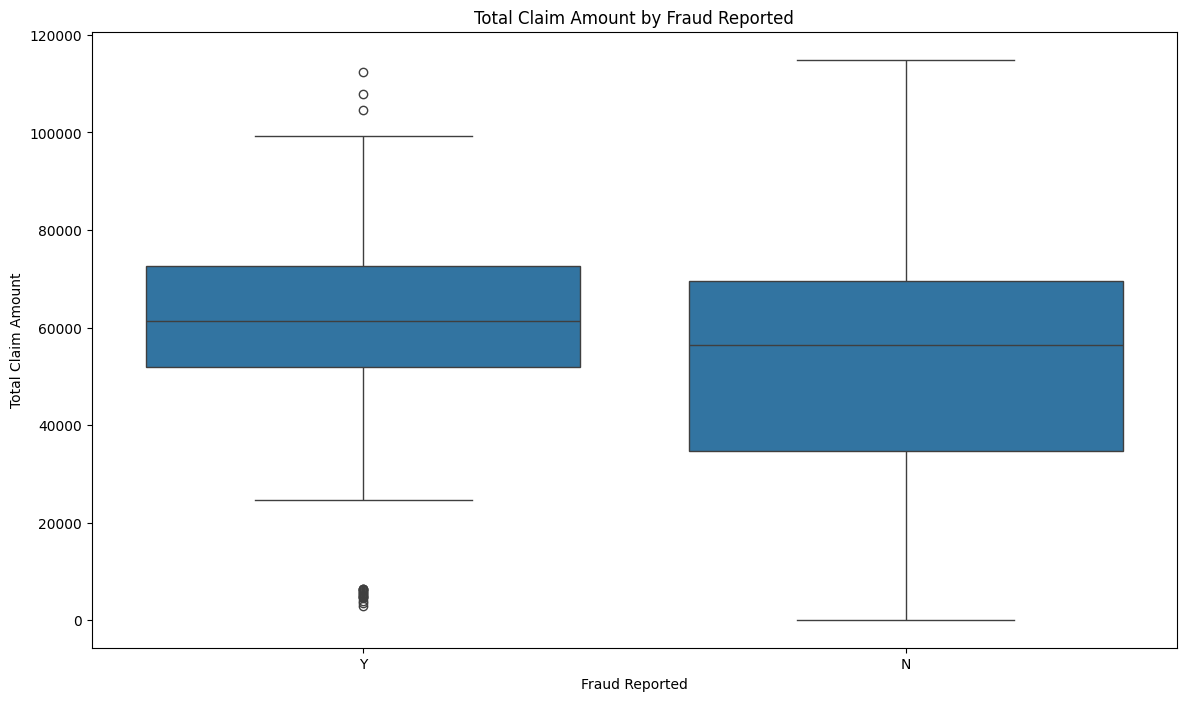

In [62]:
# Create a box plot to visualize the distribution of claim amounts for fraud and non-fraud cases
plt.figure(figsize=(14, 8))
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df1)
plt.title('Total Claim Amount by Fraud Reported')
plt.xlabel('Fraud Reported')
plt.ylabel('Total Claim Amount')
plt.show()

Box plot: total claim amount by fraud Y / N
What it shows: Per claim (row-level) distribution of total_claim_amount when fraud_reported is Y vs N — medians, spread, outliers.

How it affects insight: This is closer to “do fraudulent claims tend to be larger?” than the 0.57 aggregate correlation. You typically compare medians and IQR between Y and N. This can align with a story that fraud cases are somewhat higher or tighter in range — but the boxplot is about distributions, not vehicle totals.

Why it’s needed: Connects aggregate vehicle analysis to individual claim behavior and supports discussion of IQR/outliers you computed earlier.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\1588004036.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='fraud_reported', data=age_fraud, palette='viridis')


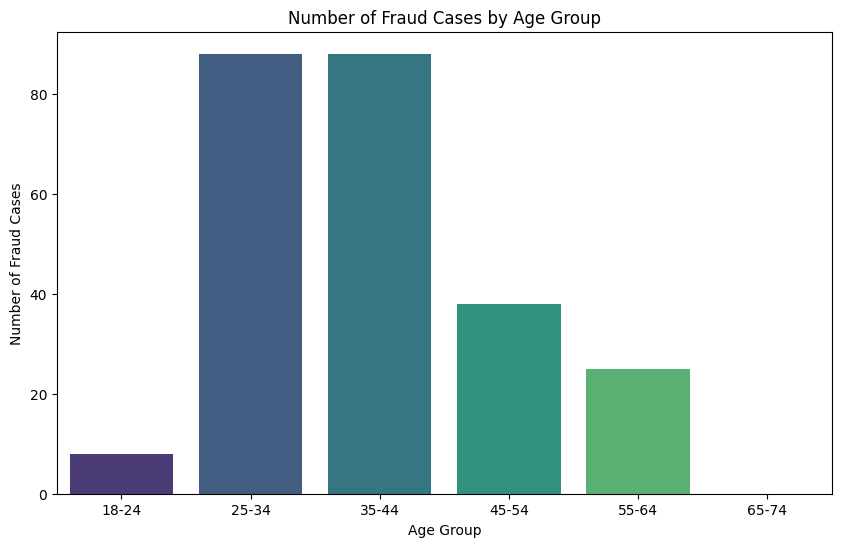

In [63]:
# we should investivate what age group exhibit thee fraudulent claims


# Create age groups
bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']
df1['age_group'] = pd.cut(df1['age'], bins=bins, labels=labels, right=False)

# Aggregate fraud count by age group
age_fraud = df1.groupby('age_group').agg({
    'fraud_reported': lambda x: (x == 'Y').sum()
}).reset_index()

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='fraud_reported', data=age_fraud, palette='viridis')
plt.title('Number of Fraud Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Fraud Cases')
plt.show()

Bar chart: fraud cases by age group
What it shows: How many fraud-labeled cases fall in each age band (counts by group).

How it affects insight: Adds who (demographics), while your correlation is about vehicle-level money vs fraud counts. Peak ages show where fraud cases concentrate in this sample (often driven by who is in the data and claim volume). It does not by itself prove causation (age → fraud).

Why it’s needed: Fraud analysis is rarely only about money; segmentation (age, region, vehicle) helps form hypotheses and communicate risk.

In [64]:
# Check the number of records for the 65-74 age group
age_group_low_fraud_count = df1[df1['age_group'] == '65-74'].shape[0]
print("Number of records for the 65-74 age group:", age_group_low_fraud_count)

Number of records for the 65-74 age group: 0


In [65]:
# Filter the data for the 25-44 age group (highest fraud cases)
age_group_high_fraud = df1[df1['age_group'].isin(['25-34', '35-44'])]

# Filter the data for the 65-74 age group (lowest fraud cases)
age_group_low_fraud = df1[df1['age_group'] == '65-74']

In [66]:
# Aggregate vehicle data for the 25-44 age group
vehicle_high_fraud = age_group_high_fraud.groupby(['auto_make', 'auto_model']).size().reset_index(name='count')

# Aggregate vehicle data for the 65-74 age group
vehicle_low_fraud = age_group_low_fraud.groupby(['auto_make', 'auto_model']).size().reset_index(name='count')

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\2548036215.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='auto_make', data=vehicle_high_fraud, palette='viridis')


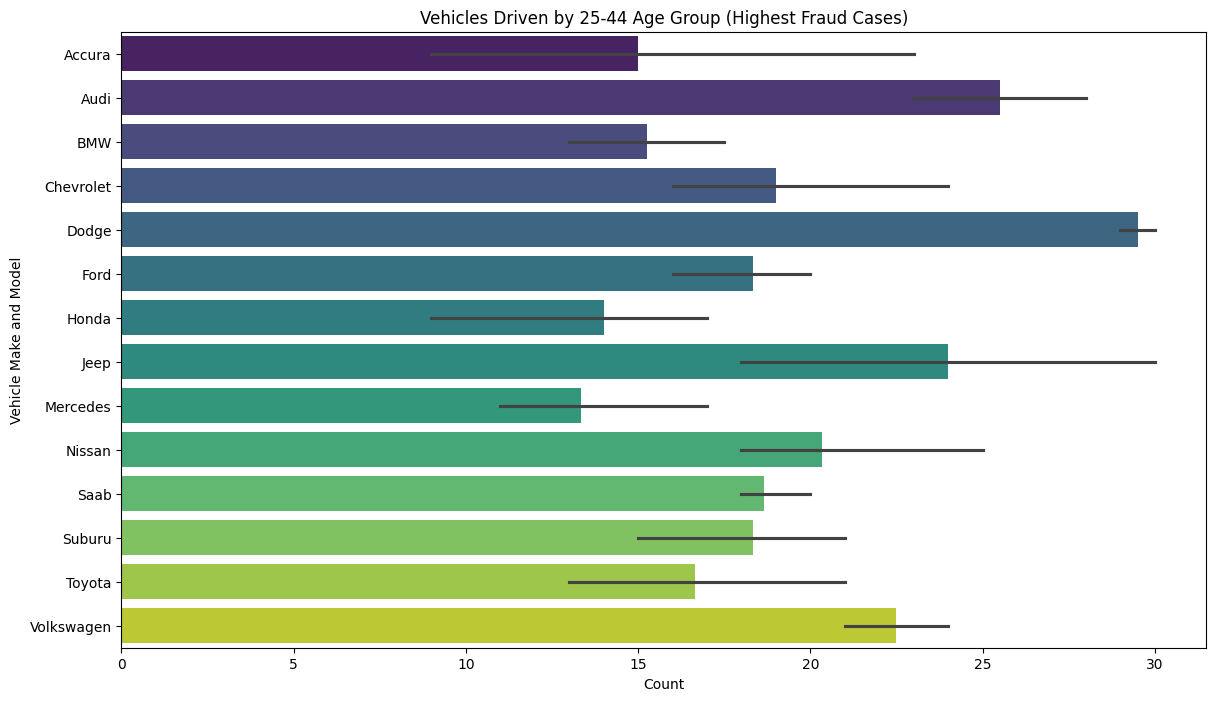

In [69]:
# Bar chart for the 25-44 age group
plt.figure(figsize=(14, 8))
sns.barplot(x='count', y='auto_make', data=vehicle_high_fraud, palette='viridis')
plt.title('Vehicles Driven by 25-44 Age Group (Highest Fraud Cases)')
plt.xlabel('Count')
plt.ylabel('Vehicle Make and Model')
plt.show()



C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\3194439221.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='incident_type', data=incident_type_counts, palette='viridis')


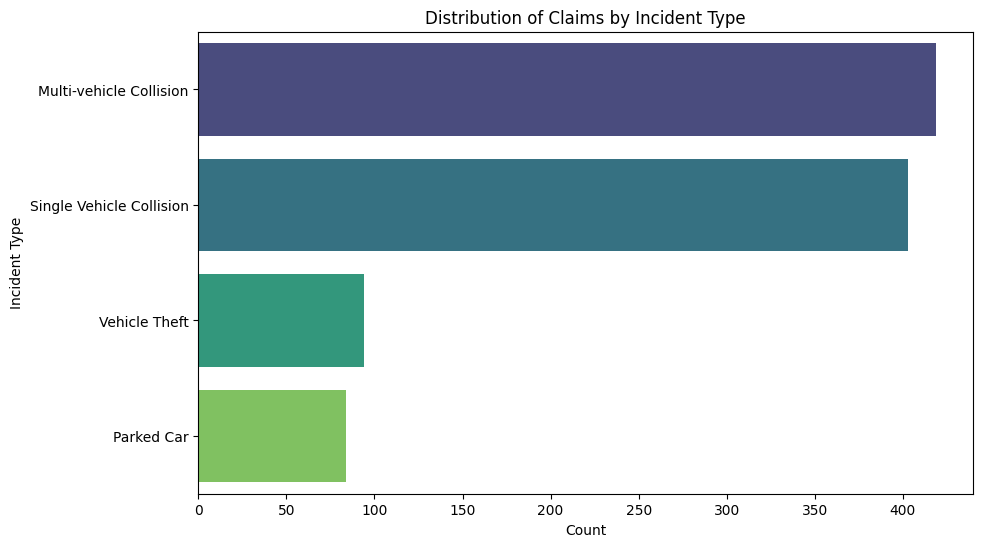

In [70]:
# Aggregate the number of claims by incident type
incident_type_counts = df1['incident_type'].value_counts().reset_index()
incident_type_counts.columns = ['incident_type', 'count']

# Sort the data by count
incident_type_counts = incident_type_counts.sort_values(by='count', ascending=False)

# Create a sorted bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='incident_type', data=incident_type_counts, palette='viridis')
plt.title('Distribution of Claims by Incident Type')
plt.xlabel('Count')
plt.ylabel('Incident Type')
plt.show()

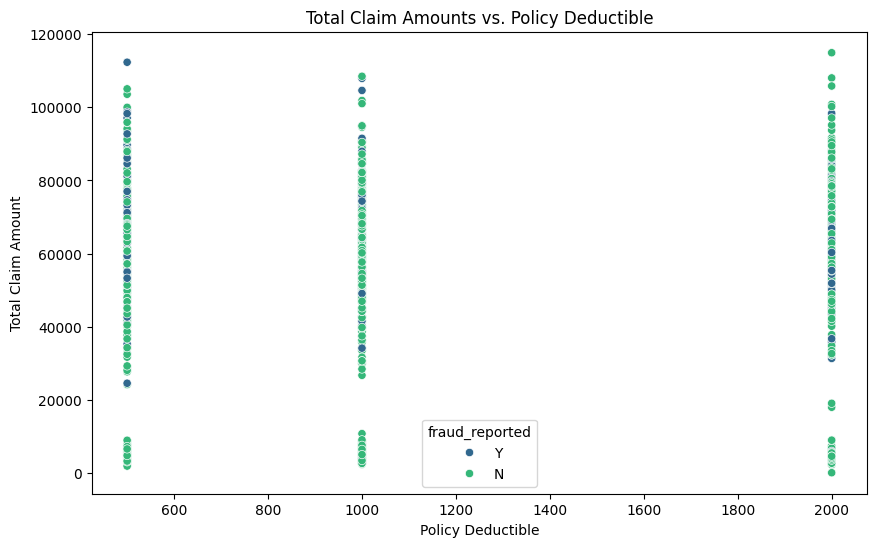

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='policy_deductable', y='total_claim_amount', data=df1, hue='fraud_reported', palette='viridis')
plt.title('Total Claim Amounts vs. Policy Deductible')
plt.xlabel('Policy Deductible')
plt.ylabel('Total Claim Amount')
plt.show()

# Key Insights:

Collision Incidents: Collisions, both multi-vehicle and single-vehicle, are the most common types of incidents leading to insurance claims. This highlights the importance of focusing on collision prevention measures.

Theft and Parked Car Incidents: While less common, vehicle theft and incidents involving parked cars still contribute to the total number of claims. Understanding the causes and patterns of these incidents can help in developing targeted prevention strategies.

Key Insights:
Relationship Between Deductibles and Claim Amounts: The scatter plot shows that there is no clear linear relationship between policy deductibles and total claim amounts. Claims with both high and low deductibles can have a wide range of total claim amounts.

Fraud Patterns: The color coding of the points indicates whether fraud was reported. By analyzing the distribution of fraud and non-fraud cases, you can identify any patterns related to policy deductibles and claim amounts. For example, you might observe that fraudulent claims tend to have higher or lower deductibles compared to non-fraudulent claims.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\1732463157.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_locations.index, x=top_locations.values, palette='viridis', ax=axes[1])
C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\1732463157.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_incident_types.index, x=top_incident_types.values, palette='magma', ax=axes[2])


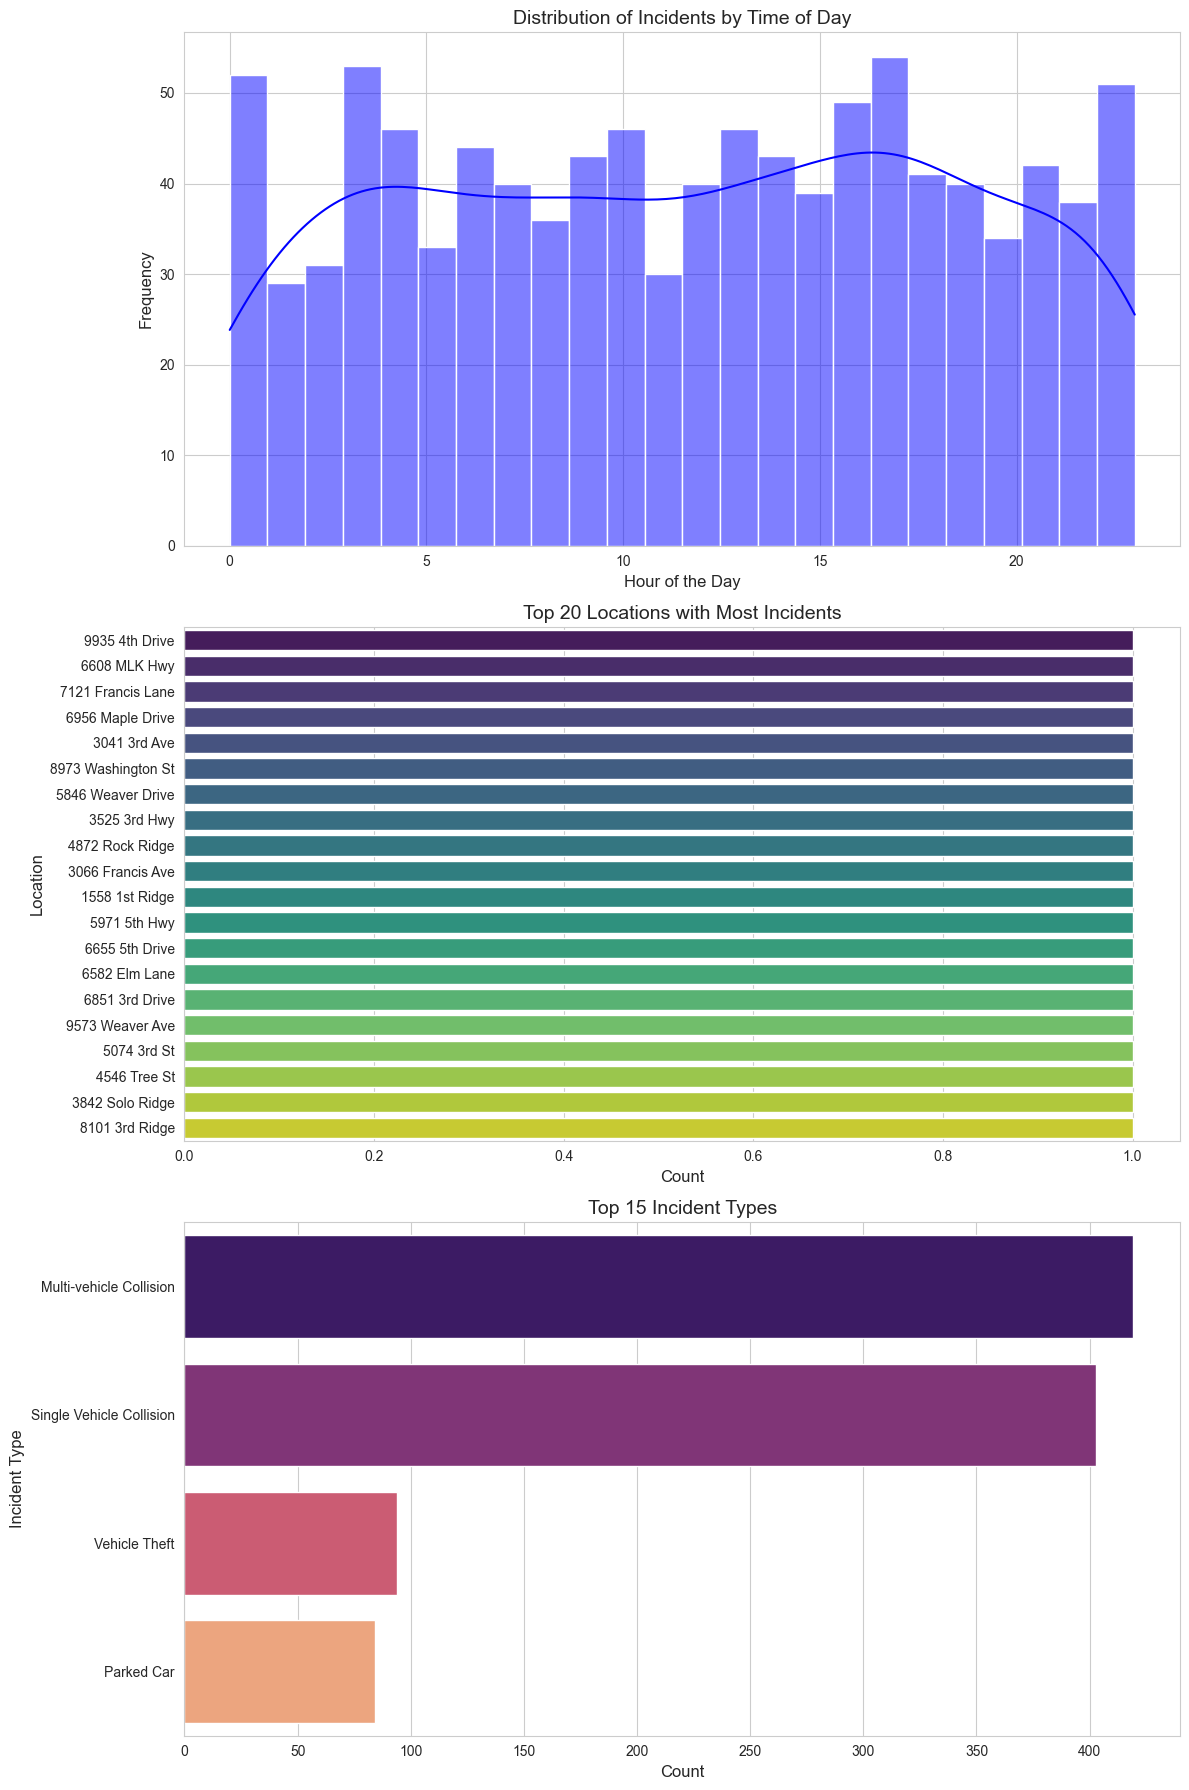

In [72]:
# Set a general style for all plots
sns.set_style("whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Distribution of Incidents by Time of Day
sns.histplot(df1['incident_hour_of_the_day'], bins=24, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribution of Incidents by Time of Day', fontsize=14)
axes[0].set_xlabel('Hour of the Day', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 2. Distribution of Incidents by Location (Top 20 locations for better readability)
top_locations = df1['incident_location'].value_counts().head(20)
sns.barplot(y=top_locations.index, x=top_locations.values, palette='viridis', ax=axes[1])
axes[1].set_title('Top 20 Locations with Most Incidents', fontsize=14)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Location', fontsize=12)

# 3. Distribution of Incidents by Type (Top 15 for readability)
top_incident_types = df1['incident_type'].value_counts().head(15)
sns.barplot(y=top_incident_types.index, x=top_incident_types.values, palette='magma', ax=axes[2])
axes[2].set_title('Top 15 Incident Types', fontsize=14)
axes[2].set_xlabel('Count', fontsize=12)
axes[2].set_ylabel('Incident Type', fontsize=12)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

# Distribution of Incidents by Time of Day
📌 Key Insights:

The number of incidents varies throughout the day, with peaks occurring at multiple times, particularly around midnight (00:00), early morning (around 5 AM), and late evening (16:00 - 22:00). A notable dip is seen during early morning hours (1 AM - 4 AM), which aligns with reduced traffic and activity. The presence of a KDE (Kernel Density Estimation) curve smooths out the distribution, indicating that incidents are more frequent during late working hours and evening rush times. Potential Fraud Indicators: If fraudulent claims are disproportionately reported during off-peak hours (e.g., 3 AM), it could signal suspicious behavior. 2. Top 20 Locations with Most Incidents 

📌 Key Insights:

The dataset reveals that incidents are highly concentrated in certain locations, with some addresses appearing significantly more often. The distribution appears almost uniform, which might indicate that data preprocessing (e.g., location encoding) has normalized it or that the dataset contains synthetic data. Potential Fraud Indicators: If certain addresses frequently report incidents, it could indicate fraud rings or high-risk zones where insurance claims are more likely to be inflated. Some locations might be hotspots for staged accidents, especially if they appear repeatedly across multiple claims. 3. Top 15 Incident Types 

📌 Key Insights:

Multi-Vehicle and Single-Vehicle Collisions are the most frequently reported incident types, which aligns with common insurance claims. Vehicle Theft and Parked Car Incidents appear significantly lower in count but still hold relevance. Potential Fraud Indicators: If single-vehicle accidents are disproportionately high compared to police reports, it may suggest fraudulent self-inflicted damage claims. A high number of multi-vehicle collisions at the same location could indicate organized fraud rings staging crashes. Low reported theft cases could mean underreporting or selective fraud focused on collisions rather than stolen vehicles.

## Feature engineering 

**Definition:** build **new columns** from existing ones (dates → parts, ratios, bins, text length) so patterns are easier to learn. We copy from `df1` into `df2` so `df1` stays the cleaned “source of truth.”

In [113]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [114]:
# Fresh load — dates as datetime for .dt features and add_features
df1 = pd.read_csv(
    "cleaned_insurance_claims.csv",
    parse_dates=["policy_bind_date", "incident_date"],
)

In [115]:
def add_features(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    out["policy_bind_date"] = pd.to_datetime(out["policy_bind_date"], errors="coerce")
    out["incident_date"] = pd.to_datetime(out["incident_date"], errors="coerce")
    out["incident_dow"] = out["incident_date"].dt.dayofweek
    out["is_weekend"] = out["incident_dow"].isin([5, 6]).astype(int)
    out["days_policy_to_incident"] = (
        out["incident_date"] - out["policy_bind_date"]
    ).dt.days
    out["premium_per_month"] = np.where(
        out["months_as_customer"] > 0,
        out["policy_annual_premium"] / out["months_as_customer"],
        np.nan,
    )
    out["claim_nonzero_injury_share"] = np.where(
        out["total_claim_amount"] > 0,
        out["injury_claim"] / out["total_claim_amount"],
        np.nan,
    )
    return out

In [116]:
df2 = add_features(df1)
df2["target"] = (
    df2["fraud_reported"].astype(str).str.upper().str.strip() == "Y"
).astype(int)

# Drop what should not be model inputs (adjust list if needed)
DROP = [
    "policy_number",
    "policy_bind_date",
    "incident_date",
    "incident_location",
    "fraud_reported",
]
df2 = df2.drop(columns=[c for c in DROP if c in df2.columns])

In [117]:
df_train, df_test = train_test_split(
    df2,
    test_size=0.25,
    stratify=df2["target"],
    random_state=42,
)
y_train = df_train["target"]
y_test = df_test["target"]
X_train_df = df_train.drop(columns=["target"])
X_test_df = df_test.drop(columns=["target"])

## Encoding, scaling, feature selection

**Encoding categorical variables:** turn categories (e.g. state, severity) into numbers models can use. Here we use **one-hot encoding** (one 0/1 column per category level).

**Standardization (z-score):** \((x - \text{mean}) / \text{std}\) per numeric column — fit on **training** data only, then apply to test.

**Normalization (min–max):** scale to a bounded range (often [0, 1]). Sensitive to extreme outliers.

**Feature selection — correlation:** linear association with the target (on training data).

**Univariate tests:** score each feature alone vs target (e.g. **mutual information**); fast, but can miss interactions unless you engineered them.

**Split first:** `df3` / `df4` below = train / test so encoders and scalers do not leak test information.

In [118]:
numeric_cols = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_df.select_dtypes(include=["object", "category"]).columns.tolist()

num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ],
    remainder="drop",
)

X_train_enc = preprocess.fit_transform(X_train_df, y_train)
X_test_enc = preprocess.transform(X_test_df)
feature_names = preprocess.get_feature_names_out()
print(X_train_enc.shape, X_test_enc.shape)
assert X_train_enc.shape[0] == len(y_train)
assert X_test_enc.shape[0] == len(y_test)

(750, 167) (250, 167)


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_30084\4213536187.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_df.select_dtypes(include=["object", "category"]).columns.tolist()


### Modeling pipeline order (single story)

1. **`df1`** — cleaned CSV; dates parsed on read.
2. **`df2`** — engineered features + `target`; drop IDs / raw dates / location text.
3. **`df3` / `df4`** — train/test split (`stratify=target`, 25% test).
4. **`numeric_cols` / `categorical_cols`** — column lists for `ColumnTransformer`.
5. **`preprocess`** — median imputation + scaling on numerics; one-hot on categoricals. **Fit on train only.**
6. **`LogisticRegression`** — binary fraud classifier; evaluate with ROC-AUC and classification report.



In [119]:
clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(X_train_enc, y_train)
y_proba = clf.predict_proba(X_test_enc)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, clf.predict(X_test_enc), digits=4))

ROC-AUC: 0.8192347288949897
              precision    recall  f1-score   support

           0     0.8450    0.8989    0.8711       188
           1     0.6200    0.5000    0.5536        62

    accuracy                         0.8000       250
   macro avg     0.7325    0.6995    0.7124       250
weighted avg     0.7892    0.8000    0.7924       250



# What ROC-AUC means here
ROC-AUC (area under the Receiver Operating Characteristic curve) summarizes how well the model ranks positive cases (fraud = 1) vs negative (not fraud = 0) using predicted probabilities, not just hard 0/1 predictions.

It uses all possible classification thresholds (not only 0.5): for each threshold you get a pair (true positive rate, false positive rate). The ROC curve plots those pairs; AUC is the area under that curve.
Scale: roughly 0.5 = random guessing; 1.0 = perfect separation.
Your value ~0.82: the model’s fraud scores tend to be higher for fraud rows than for non-fraud rows in a useful way. It’s a common overall score for imbalanced fraud problems.


ROC-AUC treats “catching fraud” and “avoiding false alarms” in a specific balance. With rare fraud, you often also care about precision and recall for class 1 separately.


Precision (for class 1)	Of all claims the model called fraud, what fraction really were fraud? High precision = fewer false alarms among predicted frauds.
Recall (for class 1)	Of all actual fraud cases, what fraction did the model catch? High recall = fewer missed frauds.
F1-score	Harmonic mean of precision and recall — one number when you want both.
Support	True count of rows of that class in the test set (188 non-fraud, 62 fraud).

Step 1 — Imports
What: Load libraries: pandas (DataFrame), numpy (math), sklearn train_test_split, ColumnTransformer, Pipeline, SimpleImputer, StandardScaler, OneHotEncoder, LogisticRegression, metrics.
Why: One place to see dependencies; sklearn gives a standard ML workflow.


Step 2 — Load cleaned_insurance_claims.csv
What: read_csv(..., parse_dates=[...]) so date columns are datetime, not strings.
Why: Feature engineering uses .dt (day of week, differences). Raw CSV strings would break that or force repeated parsing.


Step 3 — add_features
What: From df1, build new columns: incident_dow, is_weekend, days_policy_to_incident, premium_per_month, claim_nonzero_injury_share, etc.
Why: Models learn from numbers you give them; domain-motivated features (time, ratios) often help more than raw IDs alone.
Note: Ratios can be NaN (divide by zero) → handled later with imputation, not by dropping the whole row blindly.


Step 4 — df2: target + drop columns
What: target = 1 if fraud Y, else 0. Drop policy_id, raw dates, long address text, and fraud_reported so the model doesn’t use the label as a feature.
Why: Supervised learning needs a clear y; IDs don’t generalize; labels must not leak into X.


Step 5 — Train / test split
What: train_test_split with 25% test, stratify=target, random_state=42.
Why: Test simulates new claims. Stratify keeps fraud rate similar in train and test. Fixed seed makes results reproducible for teaching.


Step 6 — Preprocessing (ColumnTransformer + Pipeline)
What:
Numeric columns: SimpleImputer(median) then StandardScaler (mean 0, std 1 per feature).
Categorical columns: OneHotEncoder (one column per category level).
fit_transform on train, transform on test only.
Why:
Logistic regression needs numeric inputs and no NaN in the usual setup.
Impute on train only (median learned from train) so test data doesn’t change training statistics.
Scale so coefficients aren’t dominated by large-dollar columns.
One-hot avoids fake ordering on nominal categories (e.g. state codes).


Step 7 — Logistic regression + metrics
What: LogisticRegression fits weights on X_train_enc and y_train; predicts on X_test_enc. Print ROC-AUC and classification_report.
Why:
Logistic regression is a linear classifier + interpretable baseline.
ROC-AUC = overall ranking quality.
Classification report = precision/recall per class (especially important for fraud minority class).

We cleaned and loaded the data, engineered features that describe time and money, split into train and test so we can measure generalization, encoded categories and scaled numbers while imputing missing values from training statistics only, then trained a logistic regression fraud classifier. We report ROC-AUC for overall quality and precision/recall for fraud because fraud is rare and business cares about both missed fraud and false alarms

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Trees split on feature values; scaling is optional, but using the same X_train_enc as logistic regression is fine (fair comparison).
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,           # let trees grow; limit depth if you overfit
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",  # helps with imbalanced fraud vs non-fraud; try "balanced_subsample" or None to compare
)

rf.fit(X_train_enc, y_train)
rf_proba = rf.predict_proba(X_test_enc)[:, 1]

print("Random Forest — ROC-AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf.predict(X_test_enc), digits=4))


--- ROC-AUC summary (identical test set) ---
RF deep:             0.834977693891558
RF shallow:          0.8144303363074812


In [124]:
# --- Modeling: every model uses the SAME X_train_enc, X_test_enc, y_train, y_test ---
# Rationale: fair comparison. Changing split or preprocessing between models would make
# ROC-AUC / recall numbers incomparable (that is why an older 70/30 + raw-feature RF differed).

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


def report_model(name, model, X_test, y_true):
    """Print ROC-AUC, per-class metrics, and confusion matrix (rows: true 0,1; cols: pred 0,1)."""
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print(classification_report(y_true, pred, digits=4))
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(confusion_matrix(y_true, pred))


# Linear baseline
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_enc, y_train)
report_model("Logistic regression", lr, X_test_enc, y_test)

# Random forest: deeper ensemble (captures nonlinearities / interactions)
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
rf.fit(X_train_enc, y_train)
report_model("Random Forest (300 trees, unlimited depth)", rf, X_test_enc, y_test)

# Same pipeline, shallow trees — same idea as many tutorials (compare hyperparameters on same data)
rf_shallow = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)
rf_shallow.fit(X_train_enc, y_train)
report_model("Random Forest (100 trees, max_depth=10)", rf_shallow, X_test_enc, y_test)

print("\n--- ROC-AUC summary (identical test set) ---")
print("Logistic regression:", roc_auc_score(y_test, lr.predict_proba(X_test_enc)[:, 1]))
print("RF deep:            ", roc_auc_score(y_test, rf.predict_proba(X_test_enc)[:, 1]))
print("RF shallow:         ", roc_auc_score(y_test, rf_shallow.predict_proba(X_test_enc)[:, 1]))


=== Logistic regression ===
ROC-AUC: 0.8192347288949897
              precision    recall  f1-score   support

           0     0.8450    0.8989    0.8711       188
           1     0.6200    0.5000    0.5536        62

    accuracy                         0.8000       250
   macro avg     0.7325    0.6995    0.7124       250
weighted avg     0.7892    0.8000    0.7924       250

Confusion matrix [[TN, FP], [FN, TP]]:
[[169  19]
 [ 31  31]]

=== Random Forest (300 trees, unlimited depth) ===
ROC-AUC: 0.834977693891558
              precision    recall  f1-score   support

           0     0.7902    0.9415    0.8592       188
           1     0.5769    0.2419    0.3409        62

    accuracy                         0.7680       250
   macro avg     0.6836    0.5917    0.6001       250
weighted avg     0.7373    0.7680    0.7307       250

Confusion matrix [[TN, FP], [FN, TP]]:
[[177  11]
 [ 47  15]]

=== Random Forest (100 trees, max_depth=10) ===
ROC-AUC: 0.8144303363074812
         

How to read these three models (same test set, same features)
ROC-AUC (ranking quality)
Model	ROC-AUC
RF (300 trees, unlimited depth)	0.835 (highest)
Logistic regression	0.819
RF (100 trees, depth 10)	0.814
Meaning: AUC measures how well predicted probabilities order rows (fraud tends to score higher than non-fraud). Higher AUC = better overall ranking across thresholds.

So on AUC alone, the deep RF is best.

Fraud class (1): precision vs recall (at threshold 0.5)
Model	Precision (fraud)	Recall (fraud)
Logistic regression	0.62	0.50
RF deep	0.58	0.24
RF shallow	0.59	0.55
Meaning:

Precision: Among predicted frauds, how many are really fraud?
Recall: Among all real frauds, how many did we catch?
The deep RF has the best AUC but the lowest fraud recall (0.24) at 0.5: it is conservative — it rarely predicts “fraud,” so it misses many fraud cases even though scores are well ranked.

Logistic regression catches half the frauds (0.50 recall) with moderate precision.

Shallow RF is a middle ground: recall 0.55, precision 0.59, AUC close to logistic regression.

Confusion matrices (counts)
Interpretation: TN = true non-fraud predicted non-fraud, FP = non-fraud called fraud, FN = fraud missed, TP = fraud caught.

LR: 31 TP, 31 FN → balanced errors on fraud vs RF deep (15 TP, 47 FN) which sacrifices fraud detection for fewer false alarms on non-fraud.
RF shallow: 34 TP, 28 FN → more fraud caught than LR with similar spirit.

Which model should we “pick” for saving?
There is no single number that picks the model; it depends on business priority:

If you care most about…	Sensible choice
Highest ROC-AUC (ranking / screening lists)	RF deep
Catching fraud (recall) without tuning threshold	RF shallow or logistic regression
Interpretability + stability	Logistic regression
Fewer false alarms among predicted frauds (precision)	Compare at a fixed operating point; deep RF can look better if you lower the threshold (not visible in this table alone)
Practical teaching choice:

For this course: We will save both the preprocessor (ColumnTransformer) and one model, and document why.
A good single pick for a first deployment story: RF shallow or logistic regression — better fraud recall at 0.5 than RF deep, while AUC is still reasonable.
If the lesson is “optimize ranking”: pick RF deep but tell students you may need threshold tuning to improve recall.
Recommended for “save one + test”:
rf_shallow (100 trees, max_depth=10) or logistic regression, unless you explicitly want maximum AUC (rf deep).

In [130]:
import joblib

joblib.dump(preprocess, "fraud_preprocessor.joblib")
joblib.dump(rf_shallow, "fraud_model_rf_shallow.joblib")  # or lr, rf

['fraud_model_rf_shallow.joblib']

In [127]:
# Example: two rows from your engineered table without target
X_new_df = X_test_df.iloc[:2].copy()   # dummy: first 2 test rows
X_new_enc = preprocess.transform(X_new_df)

Load and test on new rows (same columns as X_train_df before encoding):

In [129]:
preprocess = joblib.load("fraud_preprocessor.joblib")
model = joblib.load("fraud_model_rf_shallow.joblib")

X_new_enc = preprocess.transform(X_new_df)  # same column names / types
proba = model.predict_proba(X_new_enc)[:, 1]
pred = model.predict(X_new_enc)

In [134]:
import json
import joblib
import pandas as pd

preprocess = joblib.load("fraud_preprocessor.joblib")
model = joblib.load("fraud_model_rf_shallow.joblib")

with open("sample_test_rows.json", encoding="utf-8") as f:
    payload = json.load(f)

columns = payload["feature_column_order"]
sample0 = payload["samples"][0]["features"]
X_new_df = pd.DataFrame([sample0])[columns]
X_enc = preprocess.transform(X_new_df)
print("P(fraud):", model.predict_proba(X_enc)[0, 1])
print("Expected fraud label (meta):", payload["samples"][0]["meta"]["target_fraud_1_if_yes"])

P(fraud): 0.7732471080095357
Expected fraud label (meta): 1
